<h1 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #1f2937 45%, #334155 100%);
  padding: 16px 20px;
  border-radius: 14px;
  text-align: center;
  box-shadow: 0 12px 30px rgba(0,0,0,.35);
  font-family: Arial, sans-serif;
  margin: 0;
">
Time Series Forecasting - Sales
</h1>

In [32]:
%pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [33]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
warnings.filterwarnings("ignore")

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Carga de librerias y del dataset
</h2>

In [34]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=2546&path=sales.csv"
ruta_local = os.path.join("..", "data", "raw", "sales.csv")

if os.path.exists(ruta_local):
    df = pd.read_csv(ruta_local)
else:
    df = pd.read_csv(url)

print("Forma del dataset:", df.shape)
display(df.head())

revision_calidad = pd.DataFrame({
    "tipo_de_dato": df.dtypes,
    "valores_nulos": df.isnull().sum(),
    "valores_unicos": df.nunique()
})

display(revision_calidad)

Forma del dataset: (366, 2)


,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


,tipo_de_dato,valores_nulos,valores_unicos
date,str,0,366
sales,float64,0,366


<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
El dataset tiene <span style="color:#D11A2A; font-weight:bold;">366 filas</span> y <span style="color:#D11A2A; font-weight:bold;">2 columnas</span>: <span style="color:#D11A2A; font-weight:bold;">date</span> y <span style="color:#D11A2A; font-weight:bold;">sales</span>.<br>
Tambien veo que <span style="color:#D11A2A; font-weight:bold;">no hay datos vacios</span> y que cada fecha aparece una sola vez, igual que cada valor de ventas.<br>
Lo unico que falta aqui es convertir la columna <span style="color:#D11A2A; font-weight:bold;">date</span> al formato correcto de fecha para poder construir bien la serie temporal.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Construccion de la serie temporal
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Voy a convertir <span style="color:#D11A2A; font-weight:bold;">date</span> a fecha y la voy a dejar como <span style="color:#D11A2A; font-weight:bold;">indice</span> para trabajar la serie temporal correctamente.
</div>

In [35]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df = df.set_index("date")

ts = df["sales"]

print("Primeras filas de la serie temporal:")
display(ts.head())

print("Ultimas filas de la serie temporal:")
display(ts.tail())

print("Frecuencia inferida:", pd.infer_freq(ts.index))

Primeras filas de la serie temporal:


date
2022-09-03 17:10:08.079328    55.292157
2022-09-04 17:10:08.079328    53.803211
2022-09-05 17:10:08.079328    58.141693
2022-09-06 17:10:08.079328    64.530899
2022-09-07 17:10:08.079328    66.013633
Name: sales, dtype: float64

Ultimas filas de la serie temporal:


date
2023-08-30 17:10:08.079328     989.600354
2023-08-31 17:10:08.079328     994.987326
2023-09-01 17:10:08.079328     995.814415
2023-09-02 17:10:08.079328     997.350214
2023-09-03 17:10:08.079328    1000.482785
Name: sales, dtype: float64

Frecuencia inferida: D


<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
La serie ya quedo bien construida.<br>
Ahora <span style="color:#D11A2A; font-weight:bold;">date</span> esta en formato fecha y funciona como <span style="color:#D11A2A; font-weight:bold;">indice</span>.<br>
Tambien veo que la frecuencia es <span style="color:#D11A2A; font-weight:bold;">diaria</span>, asi que el tensor de la serie es <span style="color:#D11A2A; font-weight:bold;">1 dia</span>.<br>
Ademas, comparando el inicio con el final, se nota una subida muy fuerte en las ventas, desde valores cercanos a <span style="color:#D11A2A; font-weight:bold;">55</span> hasta alrededor de <span style="color:#D11A2A; font-weight:bold;">1000</span>.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Grafica de la serie temporal
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Voy a graficar la serie para ver de forma clara la <span style="color:#D11A2A; font-weight:bold;">tendencia</span>, los cambios y el posible <span style="color:#D11A2A; font-weight:bold;">ruido</span>.
</div>

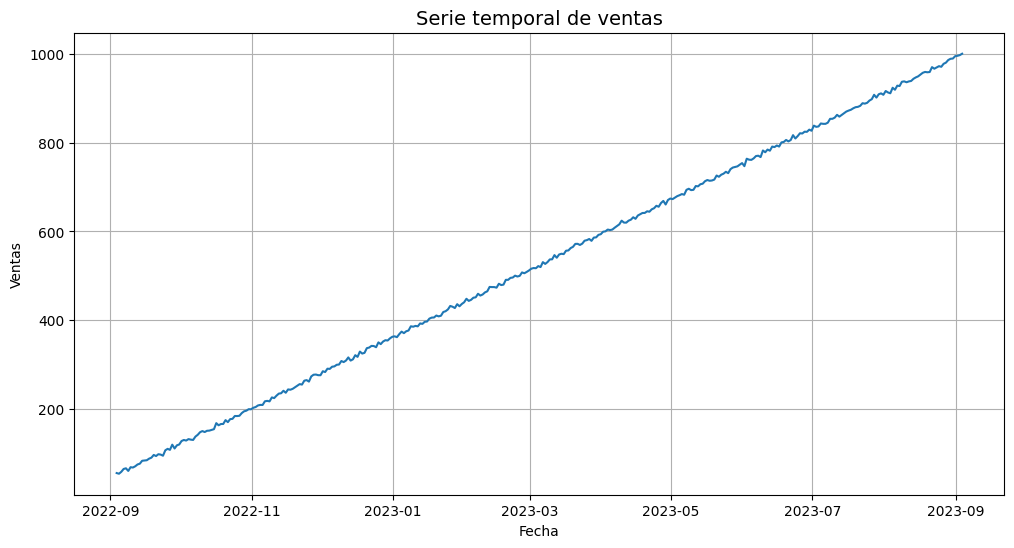

In [36]:
plt.figure(figsize=(12, 6))
plt.plot(ts.index, ts.values)
plt.title("Serie temporal de ventas", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(True)
plt.show()

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Se ve una <span style="color:#D11A2A; font-weight:bold;">tendencia claramente ascendente</span>.<br>
Las ventas suben de forma casi continua desde el inicio hasta el final, pasando de alrededor de <span style="color:#D11A2A; font-weight:bold;">55</span> a cerca de <span style="color:#D11A2A; font-weight:bold;">1000</span>.<br>
Tambien se nota que hay <span style="color:#D11A2A; font-weight:bold;">pequenas variaciones</span> en el camino, pero son bajas comparadas con la subida general.<br>
A simple vista, esta serie <span style="color:#D11A2A; font-weight:bold;">no parece estacionaria</span>, porque su nivel va cambiando mucho con el tiempo.
</div>


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Analisis de estacionariedad
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Voy a usar la prueba <span style="color:#D11A2A; font-weight:bold;">ADF</span> para comprobar si la serie es <span style="color:#D11A2A; font-weight:bold;">estacionaria</span> o no.
</div>

In [37]:
resultado_adf = adfuller(ts)

resumen_adf = pd.Series(
    resultado_adf[0:4],
    index=["estadistico_adf", "p_valor", "rezagos_usados", "n_observaciones"]
)

print("Resultado de la prueba ADF:")
display(resumen_adf)

print("Valores criticos:")
display(pd.Series(resultado_adf[4]))

Resultado de la prueba ADF:


estadistico_adf      0.545414
p_valor              0.986190
rezagos_usados      13.000000
n_observaciones    352.000000
dtype: float64

Valores criticos:


1%    -3.449065
5%    -2.869786
10%   -2.571163
dtype: float64

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Con esta prueba <span style="color:#D11A2A; font-weight:bold;">ADF</span> ya confirmo que la serie <span style="color:#D11A2A; font-weight:bold;">no es estacionaria</span>.<br>
El <span style="color:#D11A2A; font-weight:bold;">p-value = 0.9862</span> es muy alto, asi que no hay base para decir que la serie sea estable en el tiempo.<br>
Ademas, el valor de la prueba <span style="color:#D11A2A; font-weight:bold;">0.5454</span> esta por encima de todos los valores criticos, lo que va en la misma direccion.<br>
En resumen: el <span style="color:#D11A2A; font-weight:bold;">tensor</span> es <span style="color:#D11A2A; font-weight:bold;">diario</span>, la <span style="color:#D11A2A; font-weight:bold;">tendencia</span> es claramente ascendente, la serie <span style="color:#D11A2A; font-weight:bold;">no es estacionaria</span> y si hay <span style="color:#D11A2A; font-weight:bold;">algo de variacion o ruido</span>, pero la subida general domina por completo.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Division en train y test
</h2>

In [38]:
tamano_entrenamiento = int(len(ts) * 0.8)

serie_entrenamiento = ts.iloc[:tamano_entrenamiento]
serie_prueba = ts.iloc[tamano_entrenamiento:]

print("Tamano de entrenamiento:", len(serie_entrenamiento))
print("Tamano de prueba:", len(serie_prueba))

print("\nRango de fechas en entrenamiento:")
print(serie_entrenamiento.index.min(), "->", serie_entrenamiento.index.max())

print("\nRango de fechas en prueba:")
print(serie_prueba.index.min(), "->", serie_prueba.index.max())

Tamano de entrenamiento: 292
Tamano de prueba: 74

Rango de fechas en entrenamiento:
2022-09-03 17:10:08.079328 -> 2023-06-21 17:10:08.079328

Rango de fechas en prueba:
2023-06-22 17:10:08.079328 -> 2023-09-03 17:10:08.079328


<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
La division quedo bien hecha.<br>
La parte de <span style="color:#D11A2A; font-weight:bold;">train</span> tiene <span style="color:#D11A2A; font-weight:bold;">292 datos</span> y la de <span style="color:#D11A2A; font-weight:bold;">test</span> tiene <span style="color:#D11A2A; font-weight:bold;">74 datos</span>.<br>
El modelo va a aprender con los datos desde <span style="color:#D11A2A; font-weight:bold;">2022-09-03</span> hasta <span style="color:#D11A2A; font-weight:bold;">2023-06-21</span> y lo vamos a comprobar con el tramo final, desde <span style="color:#D11A2A; font-weight:bold;">2023-06-22</span> hasta <span style="color:#D11A2A; font-weight:bold;">2023-09-03</span>.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Busqueda de parametros para ARIMA
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Probare varias combinaciones de <span style="color:#D11A2A; font-weight:bold;">p</span>, <span style="color:#D11A2A; font-weight:bold;">d</span> y <span style="color:#D11A2A; font-weight:bold;">q</span> y me voy a quedar con la que de el <span style="color:#D11A2A; font-weight:bold;">AIC</span> mas bajo.
</div>

In [39]:
mejor_aic = float("inf")
mejor_orden = None
resultados_arima = []

for p in range(0, 4):
    for d in range(0, 3):
        for q in range(0, 4):
            orden = (p, d, q)
            try:
                modelo = ARIMA(serie_entrenamiento, order=orden)
                modelo_ajustado = modelo.fit()

                resultados_arima.append({
                    "orden": orden,
                    "aic": modelo_ajustado.aic
                })

                if modelo_ajustado.aic < mejor_aic:
                    mejor_aic = modelo_ajustado.aic
                    mejor_orden = orden
            except:
                continue

tabla_resultados_arima = pd.DataFrame(resultados_arima).sort_values("aic").reset_index(drop=True)

display(tabla_resultados_arima.head(10))

print("Mejor orden ARIMA:", mejor_orden)
print("Mejor AIC:", mejor_aic)

,orden,aic
0,"(0, 2, 3)",1482.360778
1,"(1, 2, 2)",1482.399299
2,"(0, 2, 2)",1483.850037
3,"(2, 2, 2)",1484.367657
4,"(1, 2, 3)",1485.911440
5,"(3, 2, 2)",1486.304298
6,"(2, 2, 3)",1486.399080
7,"(3, 2, 3)",1488.364384
8,"(2, 1, 2)",1489.279010
9,"(1, 1, 3)",1489.539551


Mejor orden ARIMA: (0, 2, 3)
Mejor AIC: 1482.3607777248235


<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
El mejor modelo por <span style="color:#D11A2A; font-weight:bold;">AIC</span> es <span style="color:#D11A2A; font-weight:bold;">ARIMA(0, 2, 3)</span> con un valor de <span style="color:#D11A2A; font-weight:bold;">1482.36</span>.<br>
Los modelos que le siguen quedan bastante cerca, asi que esta zona se ve estable y coherente.<br>
Tambien encaja con lo que vimos antes en la serie, porque al no ser <span style="color:#D11A2A; font-weight:bold;">estacionaria</span> tiene sentido trabajar con un modelo que use <span style="color:#D11A2A; font-weight:bold;">d = 2</span>.<br>
Con esto, el orden <span style="color:#D11A2A; font-weight:bold;">(0, 2, 3)</span> queda como la mejor opcion para seguir.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Entrenamiento del modelo final
</h2>

In [40]:
modelo_final = ARIMA(serie_entrenamiento, order=(0, 2, 3))
modelo_final_ajustado = modelo_final.fit()

predicciones = modelo_final_ajustado.forecast(steps=len(serie_prueba))

mae_final = mean_absolute_error(serie_prueba, predicciones)
rmse_final = np.sqrt(mean_squared_error(serie_prueba, predicciones))

print("MAE final:", mae_final)
print("RMSE final:", rmse_final)

MAE final: 2.272629772940933
RMSE final: 2.82523758230765


<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
El modelo final dio un resultado <span style="color:#D11A2A; font-weight:bold;">muy bueno</span>.<br>
El <span style="color:#D11A2A; font-weight:bold;">MAE = 2.27</span> y el <span style="color:#D11A2A; font-weight:bold;">RMSE = 2.83</span> son errores bajos frente al nivel de ventas que tiene la serie en la parte final.<br>
Dicho de forma simple, el modelo esta prediciendo las ventas con bastante cercania respecto a los valores reales.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Comparacion entre valores reales y predichos
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Voy a comparar los valores <span style="color:#D11A2A; font-weight:bold;">reales</span> con los <span style="color:#D11A2A; font-weight:bold;">predichos</span> para ver que tan cerca quedo el modelo en el tramo de prueba.
</div>

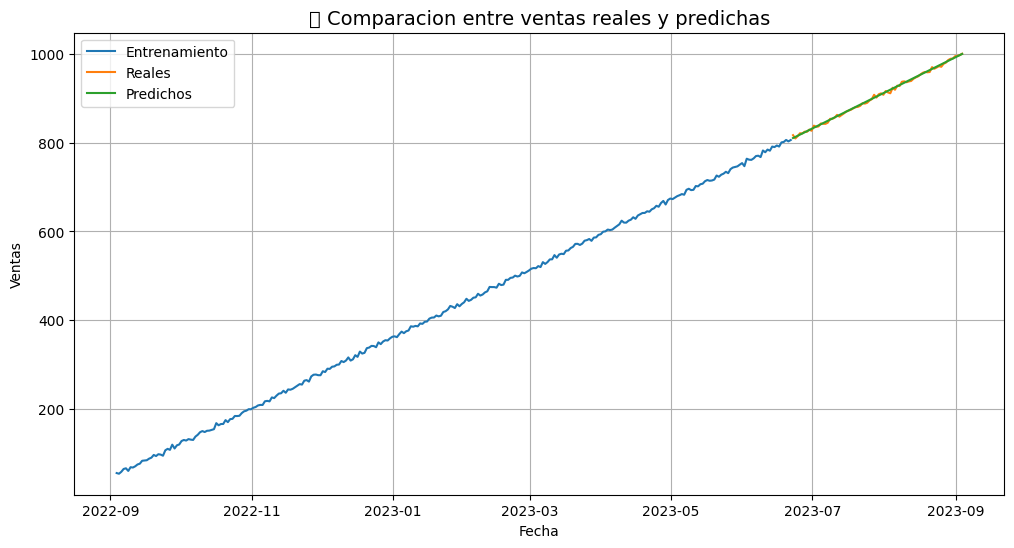

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(serie_entrenamiento.index, serie_entrenamiento.values, label="Entrenamiento")
plt.plot(serie_prueba.index, serie_prueba.values, label="Reales")
plt.plot(serie_prueba.index, predicciones.values, label="Predichos")

plt.title("📈 Comparacion entre ventas reales y predichas", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
En esta grafica se ve que la linea de <span style="color:#D11A2A; font-weight:bold;">predicciones</span> queda casi pegada a la de los valores <span style="color:#D11A2A; font-weight:bold;">reales</span> en el tramo de prueba.<br>
Eso confirma que el modelo siguio muy bien la forma de la serie en la parte final.<br>
Tambien mantiene la <span style="color:#D11A2A; font-weight:bold;">tendencia ascendente</span> y apenas se separa de los datos reales.<br>
En resumen, la prediccion fue <span style="color:#D11A2A; font-weight:bold;">muy buena</span> tanto en los numeros como en la grafica.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Comparacion con modelos cercanos
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Voy a comparar <span style="color:#D11A2A; font-weight:bold;">ARIMA(0, 2, 3)</span> con otros modelos cercanos para ver cual rinde mejor en el conjunto de <span style="color:#D11A2A; font-weight:bold;">prueba</span>.
</div>

In [42]:
ordenes_a_comparar = [(0, 2, 3), (1, 2, 2), (0, 2, 2)]

resultados_comparacion = []

for orden in ordenes_a_comparar:
    modelo = ARIMA(serie_entrenamiento, order=orden)
    modelo_ajustado = modelo.fit()
    predicciones_tmp = modelo_ajustado.forecast(steps=len(serie_prueba))

    mae = mean_absolute_error(serie_prueba, predicciones_tmp)
    rmse = np.sqrt(mean_squared_error(serie_prueba, predicciones_tmp))

    resultados_comparacion.append({
        "orden": orden,
        "aic": modelo_ajustado.aic,
        "mae": mae,
        "rmse": rmse
    })

tabla_comparacion = pd.DataFrame(resultados_comparacion).sort_values("rmse").reset_index(drop=True)
display(tabla_comparacion)

,orden,aic,mae,rmse
0,"(1, 2, 2)",1482.399299,2.268499,2.822261
1,"(0, 2, 3)",1482.360778,2.272630,2.825238
2,"(0, 2, 2)",1483.850037,4.757186,5.486022


<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
La comparacion muestra que los dos mejores modelos son <span style="color:#D11A2A; font-weight:bold;">ARIMA(1, 2, 2)</span> y <span style="color:#D11A2A; font-weight:bold;">ARIMA(0, 2, 3)</span>.<br>
Los dos quedan <span style="color:#D11A2A; font-weight:bold;">muy cerca</span>, pero <span style="color:#D11A2A; font-weight:bold;">ARIMA(1, 2, 2)</span> gana por un margen pequeno porque tiene el <span style="color:#D11A2A; font-weight:bold;">MAE</span> y el <span style="color:#D11A2A; font-weight:bold;">RMSE</span> mas bajos.<br>
En cambio, <span style="color:#D11A2A; font-weight:bold;">ARIMA(0, 2, 2)</span> ya se aleja bastante y comete mas error.<br>
En resumen, si nos guiamos por el rendimiento en <span style="color:#D11A2A; font-weight:bold;">prueba</span>, el modelo que conviene dejar como final es <span style="color:#D11A2A; font-weight:bold;">ARIMA(1, 2, 2)</span>.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Ajuste del modelo final elegido
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Voy a dejar como modelo final <span style="color:#D11A2A; font-weight:bold;">ARIMA(1, 2, 2)</span> porque fue el que mejor rindio en el conjunto de <span style="color:#D11A2A; font-weight:bold;">prueba</span>.
</div>

In [43]:
modelo_final = ARIMA(serie_entrenamiento, order=(1, 2, 2))
modelo_final_ajustado = modelo_final.fit()

predicciones = modelo_final_ajustado.forecast(steps=len(serie_prueba))

mae_final = mean_absolute_error(serie_prueba, predicciones)
rmse_final = np.sqrt(mean_squared_error(serie_prueba, predicciones))

print("MAE final:", mae_final)
print("RMSE final:", rmse_final)

MAE final: 2.2684992489546127
RMSE final: 2.8222614014317227


<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
El modelo final dio un resultado <span style="color:#D11A2A; font-weight:bold;">muy bueno</span>.<br>
El <span style="color:#D11A2A; font-weight:bold;">MAE = 2.27</span> y el <span style="color:#D11A2A; font-weight:bold;">RMSE = 2.82</span> son errores bajos frente al nivel de ventas que maneja la serie en la parte final.<br>
Ademas, este modelo no solo salio bien por numeros, sino que tambien fue el que mejor rindio al compararlo con las otras opciones cercanas.<br>
Por eso, <span style="color:#D11A2A; font-weight:bold;">ARIMA(1, 2, 2)</span> queda como el modelo final del proyecto.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Comparacion entre valores reales y predichos
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Voy a comparar los valores <span style="color:#D11A2A; font-weight:bold;">reales</span> con los <span style="color:#D11A2A; font-weight:bold;">predichos</span> para ver que tan cerca quedo el modelo en el tramo de prueba.
</div>

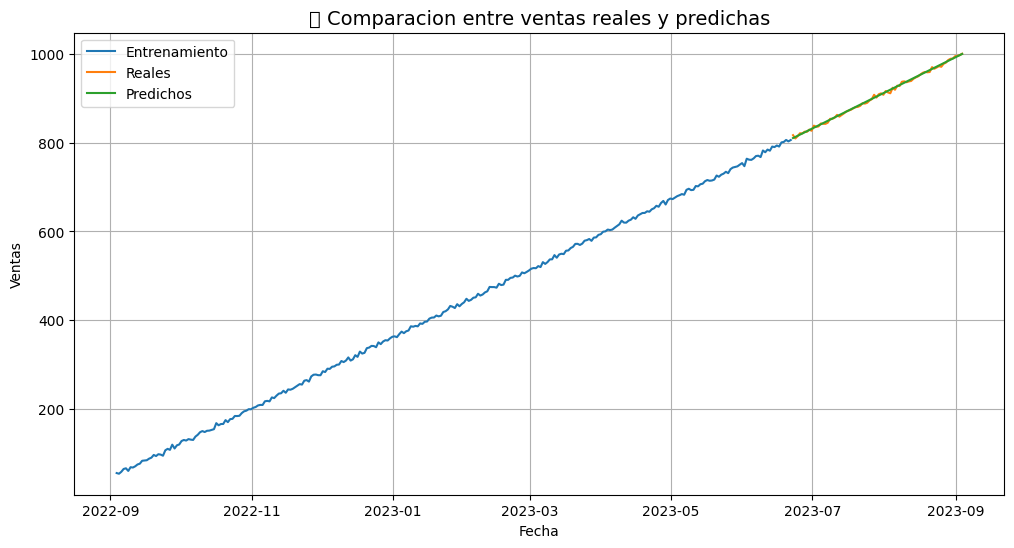

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(serie_entrenamiento.index, serie_entrenamiento.values, label="Entrenamiento")
plt.plot(serie_prueba.index, serie_prueba.values, label="Reales")
plt.plot(serie_prueba.index, predicciones.values, label="Predichos")

plt.title("📈 Comparacion entre ventas reales y predichas", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
En esta grafica se ve que la linea de <span style="color:#D11A2A; font-weight:bold;">predicciones</span> queda casi pegada a la de los valores <span style="color:#D11A2A; font-weight:bold;">reales</span> en el tramo de prueba.<br>
Eso confirma que el modelo siguio muy bien la forma de la serie en la parte final.<br>
Tambien mantiene la <span style="color:#D11A2A; font-weight:bold;">tendencia ascendente</span> y apenas se separa de los datos reales.<br>
En resumen, la prediccion fue <span style="color:#D11A2A; font-weight:bold;">muy buena</span> tanto en los numeros como en la grafica.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Tabla de comparacion entre modelos
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #38bdf8;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
Voy a resumir los resultados de los modelos comparados para dejar mas clara la eleccion del modelo final.
</div>

In [45]:
tabla_resumen_modelos = tabla_comparacion.copy()
tabla_resumen_modelos["aic"] = tabla_resumen_modelos["aic"].round(3)
tabla_resumen_modelos["mae"] = tabla_resumen_modelos["mae"].round(3)
tabla_resumen_modelos["rmse"] = tabla_resumen_modelos["rmse"].round(3)

display(tabla_resumen_modelos)

,orden,aic,mae,rmse
0,"(1, 2, 2)",1482.399,2.268,2.822
1,"(0, 2, 3)",1482.361,2.273,2.825
2,"(0, 2, 2)",1483.850,4.757,5.486


<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
La tabla deja clara la comparacion final.<br>
<span style="color:#D11A2A; font-weight:bold;">ARIMA(1, 2, 2)</span> fue el que mejor rindio, porque obtuvo el <span style="color:#D11A2A; font-weight:bold;">MAE</span> y el <span style="color:#D11A2A; font-weight:bold;">RMSE</span> mas bajos.<br>
<span style="color:#D11A2A; font-weight:bold;">ARIMA(0, 2, 3)</span> quedo muy cerca, asi que tambien era una opcion valida.<br>
En cambio, <span style="color:#D11A2A; font-weight:bold;">ARIMA(0, 2, 2)</span> se alejo bastante del resto y mostro un error claramente mayor.<br>
Por eso, el modelo final del proyecto queda como <span style="color:#D11A2A; font-weight:bold;">ARIMA(1, 2, 2)</span>.
</div>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Guardado del modelo
</h2>

In [46]:
ruta_modelo = os.path.join("..", "models", "arima_sales_model.pkl")

with open(ruta_modelo, "wb") as archivo:
    pickle.dump(modelo_final_ajustado, archivo)

print("Modelo guardado en:", ruta_modelo)

Modelo guardado en: ../models/arima_sales_model.pkl


<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 14px 18px;
  border-radius: 12px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #38bdf8;
  margin: 14px 0 0 0;
  font-size: 20px;
">
Conclusion final
</h2>

<div style="
  font-size: 16px;
  line-height: 1.55;
  background-color: #ececec;
  border-left: 6px solid #22c55e;
  padding: 16px;
  border-radius: 10px;
  color: #111827;
  margin-top: 10px;
">
En este proyecto construi una <span style="color:#D11A2A; font-weight:bold;">serie temporal diaria</span> con los datos de ventas y vi que tenia una <span style="color:#D11A2A; font-weight:bold;">tendencia claramente ascendente</span>.<br>
La prueba <span style="color:#D11A2A; font-weight:bold;">ADF</span> confirmo que la serie <span style="color:#D11A2A; font-weight:bold;">no es estacionaria</span>, algo que tambien se veia en la grafica por la subida constante de las ventas.<br>
Despues compare varios modelos <span style="color:#D11A2A; font-weight:bold;">ARIMA</span> y vi que los dos mas fuertes fueron <span style="color:#D11A2A; font-weight:bold;">ARIMA(1, 2, 2)</span> y <span style="color:#D11A2A; font-weight:bold;">ARIMA(0, 2, 3)</span>.<br>
El modelo final fue <span style="color:#D11A2A; font-weight:bold;">ARIMA(1, 2, 2)</span> porque logro el mejor resultado en prueba, con un <span style="color:#D11A2A; font-weight:bold;">MAE de 2.27</span> y un <span style="color:#D11A2A; font-weight:bold;">RMSE de 2.82</span>.<br>
Ademas, en la grafica final las predicciones quedaron casi pegadas a los valores reales, lo que confirma que el modelo siguio muy bien el comportamiento de la serie.<br>
Por ultimo, el modelo quedo <span style="color:#D11A2A; font-weight:bold;">guardado</span> en la carpeta correspondiente para poder reutilizarlo despues.
</div>